<img src="../../shared/alchemi-banner-left.png" alt="NVIDIA ALCHEMI: AI for Chemistry and Materials Science" style="display:block;box-sizing:border-box;width:100%;max-width:100%;height:auto;">

<style>
h1 {
  font-size: 2.35rem !important;
  line-height: 1.15 !important;
  margin: 0.7rem 0 1rem !important;
}
h2 {
  font-size: 1.9rem !important;
  line-height: 1.2 !important;
  margin: 0.6rem 0 1rem !important;
}
h3 {
  font-size: 1.35rem !important;
  line-height: 1.3 !important;
  margin: 1.9rem 0 0.75rem !important;
}
h4 {
  font-size: 1.08rem !important;
  line-height: 1.35 !important;
  margin: 1.35rem 0 0.65rem !important;
}
.alchemi-api-label,
span[aria-label="ALCHEMI Toolkit API"] {
  color: currentColor !important;
  font-size: 0.70rem !important;
  font-weight: 700;
  letter-spacing: 0.05em;
}
@supports (color: color-mix(in srgb, black, white)) {
  .alchemi-api-label,
  span[aria-label="ALCHEMI Toolkit API"] {
    color: color-mix(in srgb, currentColor 68%, #76B900 32%) !important;
  }
}
</style>

# ALCHEMI Core · Module 1: Data and batching

**Goal:** Convert molecular structures into validated Toolkit data, inspect a heterogeneous `Batch`, compare batched execution, and save model-ready records with Zarr.

**Module 1 of 3** · [Module 2 · Models and simulation →](alchemi-core-02-models-and-simulation.ipynb)


Ammonia, propyne, and phenol stay with us through Modules 1 and 2. Here you will convert them to `AtomicData`, pack them into a `Batch`, save them, and load them again. Module 2 uses the same structures for energy and force inference, hooks, and geometry optimization.

This module runs on CPU or CUDA. Use a CUDA-capable GPU for the full course run.

In [1]:
import shutil
import tempfile
import warnings
from pathlib import Path

import torch
from ase.build import molecule
from helpers import core as helpers
from nvalchemi.data import (
    AtomicData,
    AtomicDataZarrReader,
    AtomicDataZarrWriter,
    Batch,
    DataLoader,
    Dataset,
)
from nvalchemi.models import AIMNet2Wrapper
from nvalchemi.neighbors import compute_neighbors

warnings.filterwarnings(
    "ignore",
    message="Converting a tensor with requires_grad=True to a scalar.*",
    module="nvalchemi.models.aimnet2",
)
warnings.filterwarnings(
    "ignore",
    message='install "ipywidgets".*',
    module="rich.live",
)


In [2]:
helpers.configure_tutorial()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DTYPE = torch.float32

if device.type == "cuda":
    print(
        f"Compute device: cuda:{torch.cuda.current_device()} · "
        f"{torch.cuda.get_device_name(device)}"
    )
else:
    print("Compute device: CPU")

Compute device: cuda:0 · NVIDIA RTX 4000 SFF Ada Generation


<hr class="alchemi-section-divider" aria-hidden="true" style="border:0;border-top:1px solid #D6D9D4;margin:2.4rem 0 1rem;">

## Where NVIDIA ALCHEMI fits

[NVIDIA ALCHEMI](https://developer.nvidia.com/cuda/cuda-x-libraries/alchemi) brings together reusable Python tools, accelerated atomistic operations, and deployable services.

- **ALCHEMI Toolkit** provides data, model, hook, dynamics, training, and distributed APIs for atomistic workflows.  
  📦 [Source](https://github.com/NVIDIA/nvalchemi-toolkit) · [Documentation](https://nvidia.github.io/nvalchemi-toolkit/)
- **Toolkit-Ops** provides accelerated operations for neighbor lists, reductions, dynamics, dispersion, and electrostatics.  
  📦 [Source](https://github.com/NVIDIA/nvalchemi-toolkit-ops) · [Documentation](https://nvidia.github.io/nvalchemi-toolkit-ops/)
- **ALCHEMI NIM microservices** package supported workflows such as batched relaxation and molecular dynamics as deployable services.  
  📘 [Documentation](https://docs.nvidia.com/nim/alchemi/alchemi-bgr/latest/index.html)

Module 1 begins with Toolkit's data APIs: `AtomicData`, `Batch`, `Reader`, `Dataset`, and `DataLoader`.

## How batching changes computational chemistry

High-throughput computational chemistry traditionally spreads independent calculations across jobs, devices, and HPC nodes. GPU batching packs many atomic systems into one `Batch` and evaluates them in one model call on one device.

`1 MLIP evaluation → 1 call → 1 device`  
`N MLIP evaluations → 1 Batch → 1 model call → 1 GPU`

This preview repeats ammonia to isolate the effect of call shape. CUDA evaluates 2,048 molecules; a CPU walkthrough evaluates 128. Neighbor construction and one warm call happen before timing. Each route is measured once, and the individual route includes its Python call loop.

**Predict:** Which route will use more PyTorch peak allocated memory, and which will deliver higher throughput?

In [3]:
BENCHMARK_MOLECULES = 2_048 if device.type == "cuda" else 128

ammonia = molecule("NH3")
ammonia.info["charge"] = 0
ammonia_data = AtomicData.from_atoms(ammonia, device=device)
opening_batch = Batch.from_data_list(
    [ammonia_data] * BENCHMARK_MOLECULES, device=device
)

In [4]:
single_batch = Batch.from_data_list([ammonia_data], device=device)

model = AIMNet2Wrapper.from_checkpoint(
    "aimnet2-wb97m-d3_0", device=device, compile_model=False
).eval().requires_grad_(False)
model.set_config("active_outputs", {"energy", "forces"})

# Neighbor construction adds the fields requested by this model.
for prepared_batch in (single_batch, opening_batch):
    compute_neighbors(
        prepared_batch,
        config=model.model_config.neighbor_config,
    )
    _ = model(prepared_batch)  # Warm this call shape before measuring it.

In [5]:
with helpers.measure_torch_execution(device) as individual_measurement:
    for _ in helpers.benchmark_progress(
        BENCHMARK_MOLECULES,
        description="Individual energy + force calls",
    ):
        individual_output = model(single_batch)

with helpers.measure_torch_execution(device) as batch_measurement:
    batch_output = model(opening_batch)

In [6]:
batching_results = helpers.summarize_batching_benchmark(
    device=device,
    molecule="ammonia",
    molecules=BENCHMARK_MOLECULES,
    atoms=opening_batch.num_nodes,
    individual=individual_measurement,
    batch=batch_measurement,
    batch_output=batch_output,
)

Energy + forces | 2,048 ammonia molecules | 8,192 atoms | GPU
individual calls      22.65 s | 90 molecules/s | peak allocated 26 MiB
one Batch call         0.06 s | 35,970 molecules/s | peak allocated 366 MiB
Batch outputs | energy torch.Size([2048, 1]) | forces torch.Size([8192, 3])



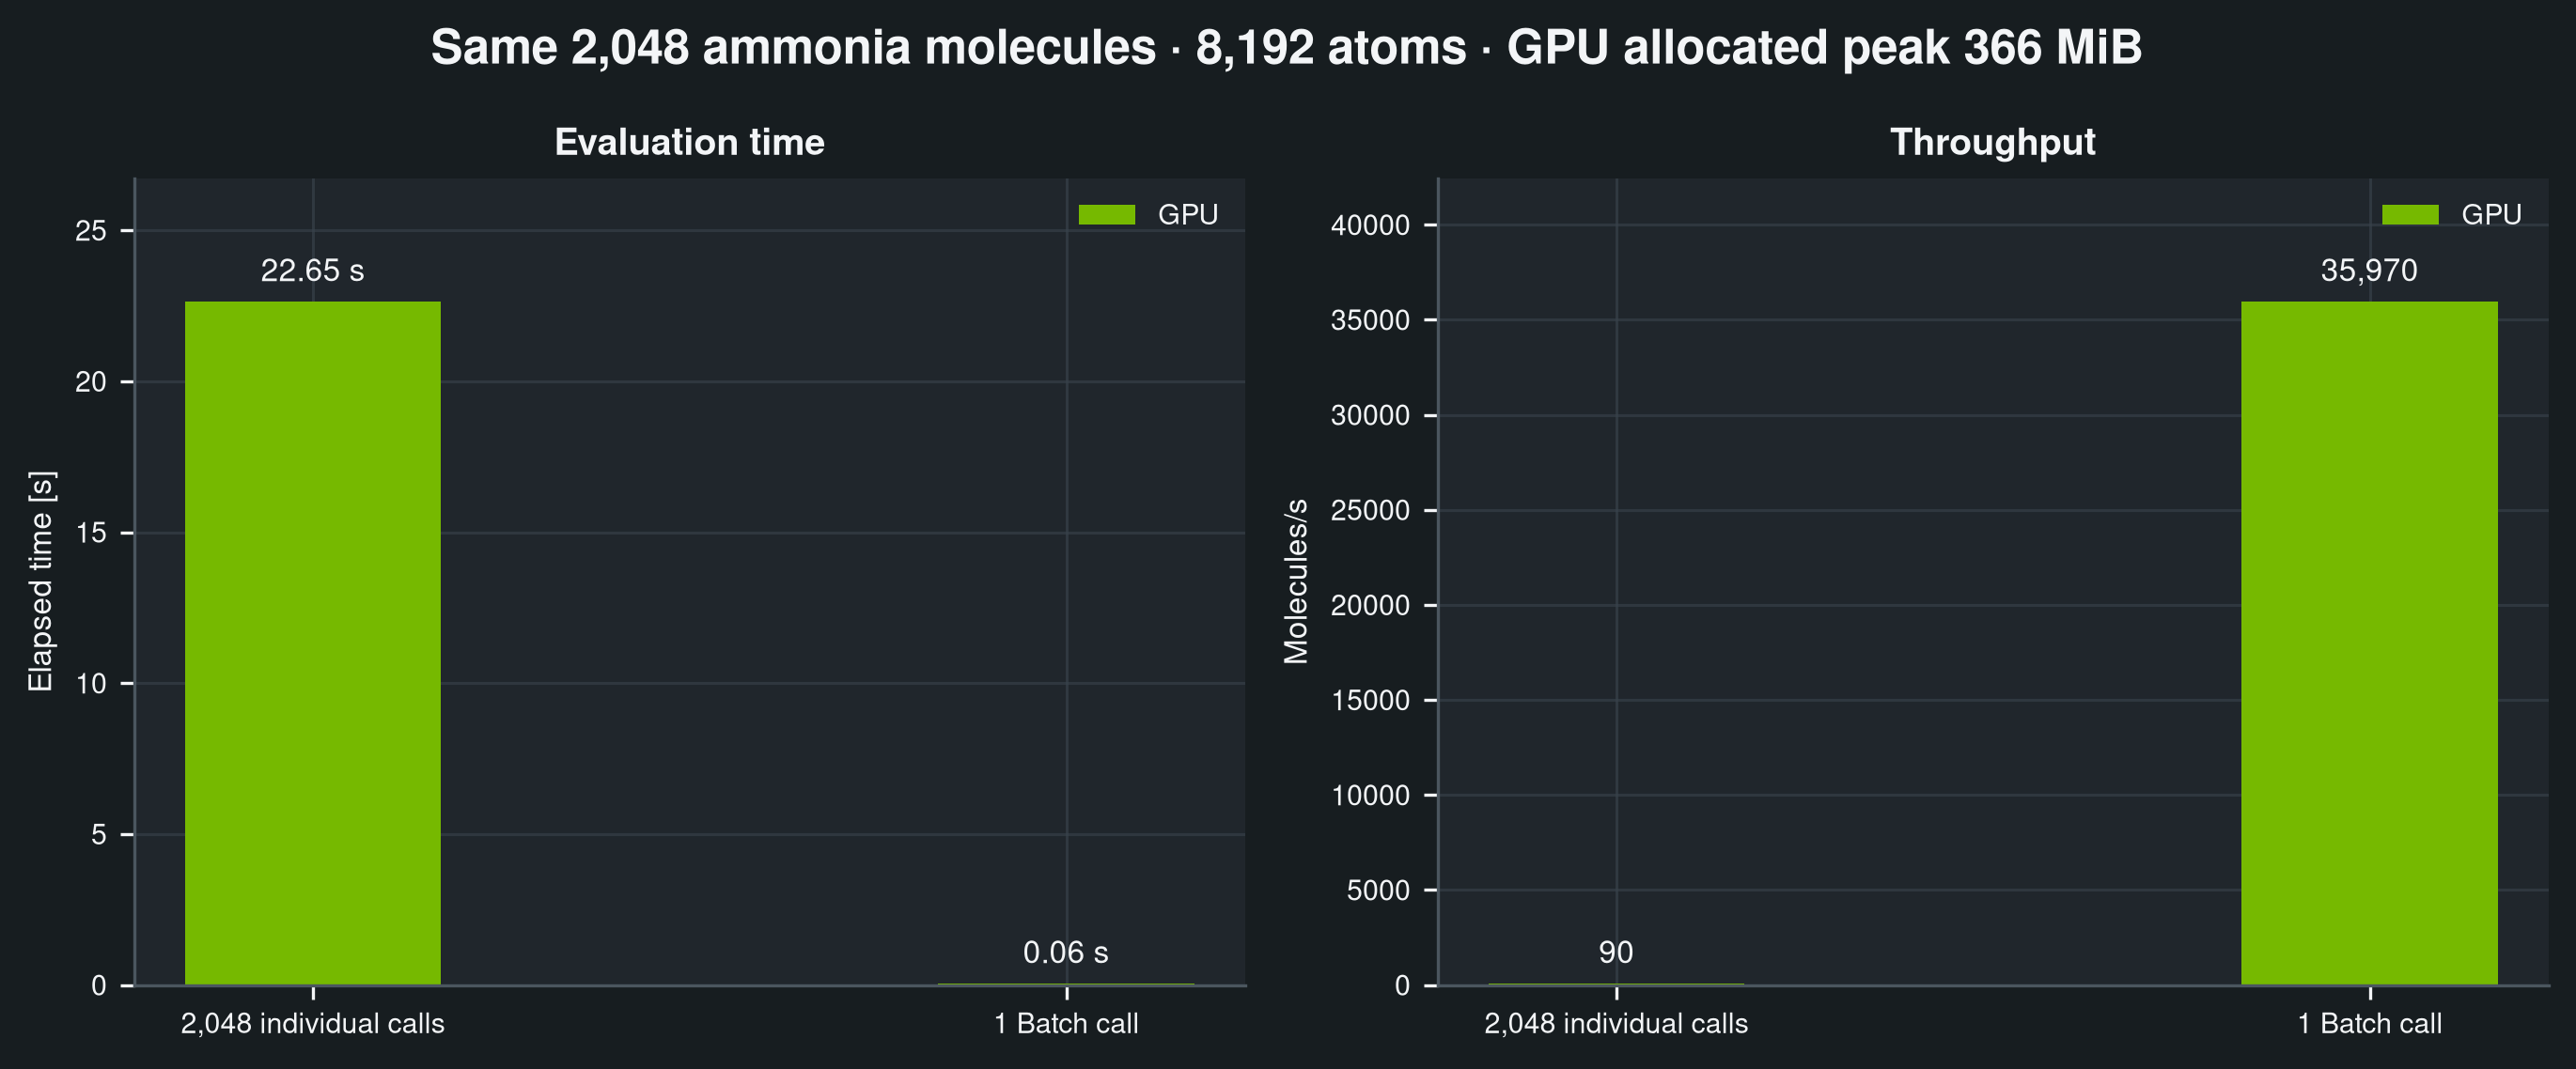

In [7]:
helpers.plot_batching_benchmark(batching_results)

### Read the opening result

Both routes evaluated the same repeated ammonia workload with the same AIMNet2 checkpoint, requested outputs, and prepared neighbors. The one-`Batch` route made one model call and completed much faster on this measured device.

The energy output has one row per molecule. The force output has one Cartesian vector per atom. The ratio below is a one-run observation for this workload and machine.

In [8]:
call_shape_ratio = (
    batching_results["individual_seconds"] / batching_results["batch_seconds"]
)
print(
    f"One Batch call: {batching_results['batch_seconds']:.3f} s | "
    f"{call_shape_ratio:.1f}× the throughput of individual calls. More capable GPUs can increase throughput."
)

# Release the large preview workload before the data lesson.
del model, single_batch, opening_batch, batch_output, individual_output
if device.type == "cuda":
    torch.cuda.empty_cache()

One Batch call: 0.057 s | 397.8× the throughput of individual calls. More capable GPUs can increase throughput.


The opening used the public Toolkit path that the rest of this course develops:

`ASE Atoms → AtomicData.from_atoms(...) → Batch.from_data_list(...) → compute_neighbors(...) → model(batch)`

The next sections rerun the data steps with small objects, inspect their fields and boundaries, and show validation in action. Module 2 returns to the model and neighbor calls.

<hr class="alchemi-section-divider" aria-hidden="true" style="border:0;border-top:1px solid #D6D9D4;margin:2.4rem 0 1rem;">

## 1 · Represent one molecule as `AtomicData`

Start with the data objects carried through Toolkit workflows: one atomic system, then a `Batch` of systems, then stored records that load back into a `Batch`.

### Rebuild the ASE molecule

Rerun the first two construction lines from the opening. `molecule("NH3")` returns an ASE `Atoms` object with element symbols and Cartesian positions in Å. Its `Atoms.info` mapping carries the net charge into `AtomicData.from_atoms(...)`.

In [9]:
ammonia = molecule("NH3")
ammonia.info["charge"] = 0

Inspect the ASE structure before conversion: formula, atom count, net charge, coordinate unit, and positions.

In [10]:
print(ammonia)
print(
    f"{ammonia.get_chemical_formula()} · {len(ammonia)} atoms · "
    f"net charge {ammonia.info['charge']:+d} e · positions in Å"
)

Atoms(symbols='NH3', pbc=False)
H3N · 4 atoms · net charge +0 e · positions in Å


### Inspect and measure the ASE molecule

Rotate ammonia and click an atom to inspect its element, atomic number, and zero-based atom row. Select two atoms to measure their distance. For an angle, select endpoint → vertex → endpoint; the second atom is the vertex. A fourth click starts a new measurement.

In [11]:
helpers.show_molecule(ammonia, height=320)

### Convert ASE atoms to Toolkit AtomicData

Use `AtomicData.from_atoms(...)` when a chemistry library, file reader, or simulation provides an ASE `Atoms` object. Toolkit validates the mapped fields and places its tensors on the requested compute device.

A pymatgen-enabled project can pass a `Structure` or `Molecule` to `AtomicData.from_structure(...)`. ASE and pymatgen own file-format parsing; Toolkit receives the resulting structure object.

> <span aria-label="ALCHEMI Toolkit API" class="alchemi-api-label">&lt;/&gt;&nbsp; API</span>
>
> `AtomicData.from_atoms(atoms, device=device)`
>
> **Input:** an ASE `Atoms` object and a target device  
> **Result:** a new validated `AtomicData` object whose tensors live on that device

**Toolkit example:** [ASE integration](https://nvidia.github.io/nvalchemi-toolkit/examples/basic/03_ase_integration.html)

In [12]:
ammonia_data = AtomicData.from_atoms(ammonia, device=device)

In [13]:
print("atomic numbers:", ammonia_data.atomic_numbers.tolist())
print("positions:     ", ammonia_data.positions.shape)
print("charge:        ", ammonia_data.charge.item())
print("device:        ", ammonia_data.device)

atomic numbers: [7, 1, 1, 1]
positions:      torch.Size([4, 3])
charge:         0.0
device:         cuda:0


### Construct `AtomicData` directly from tensors

Use the public constructor when a reader or simulation already supplies tensors. Here we describe the same ammonia molecule with one atomic-number row and one Cartesian coordinate row per atom, plus one system charge.

> <span aria-label="ALCHEMI Toolkit API" class="alchemi-api-label">&lt;/&gt;&nbsp; API</span>
>
> `AtomicData(atomic_numbers=..., positions=..., charge=...)`
>
> **Input:** node tensors plus optional system-level fields  
> **Result:** a new validated `AtomicData` object

In [14]:
# Use the constructor when the source data already arrive as tensors.

atomic_numbers = torch.tensor(
    [7, 1, 1, 1], dtype=torch.int32, device=device
)
positions = torch.tensor(
    [[0.000000, 0.000000, 0.116489],
     [0.000000, 0.939731, -0.271808],
     [0.813831, -0.469865, -0.271808],
     [-0.813831, -0.469865, -0.271808]],
    dtype=DTYPE, device=device,
)
charge = torch.tensor([[0.0]], dtype=DTYPE, device=device)

In [15]:
direct_ammonia_data = AtomicData(
    atomic_numbers=atomic_numbers,
    positions=positions,
    charge=charge,
)

### Compare the two construction routes

`AtomicData.__eq__` compares a structural hash built from atomic numbers, absolute positions, the cell, and periodic boundary flags. Field-wise checks cover charge, model targets, labels, and metadata.

In [16]:
print("same structural hash:", ammonia_data == direct_ammonia_data)
print("same positions:", torch.allclose(ammonia_data.positions, direct_ammonia_data.positions))
print("same charge:", torch.equal(ammonia_data.charge, direct_ammonia_data.charge))
print(
    "same field names:",
    set(ammonia_data.model_dump(exclude_none=True))
    == set(direct_ammonia_data.model_dump(exclude_none=True)),
)

same structural hash: True
same positions: True
same charge: True
same field names: True


#### Try it: build the amide ion NH<sub>2</sub><sup>−</sup>

> ✏️ **TRY IT**
>
> Start from the ammonia tensors above. Remove one hydrogen from both `atomic_numbers` and `positions`, construct a new `AtomicData` object, then add its −1 e system charge with `add_system_property(...)`.
>
> **Success:** `amide_anion` has 3 atoms and its system charge is −1 e.

> <span aria-label="ALCHEMI Toolkit API" class="alchemi-api-label">&lt;/&gt;&nbsp; API</span>
>
> `data.add_system_property("charge", value)`
>
> **Input:** an `AtomicData` object, a field name, and one system-level value  
> **Result:** the same object updated in place with a registered system property

In [17]:
amide_anion = None

# Your turn: replace the three ... placeholders, then uncomment.
# amide_anion = AtomicData(
#     atomic_numbers=...,
#     positions=...,
# )
# amide_anion.add_system_property("charge", ...)
# print(amide_anion.num_nodes, amide_anion.charge.item())

In [18]:
helpers.check_amide_anion(amide_anion);

Complete the exercise cell, then run this check again.


> ✅ **SAMPLE SOLUTION**

<details>
<summary><strong>Open the sample solution</strong></summary>

```python
amide_anion = AtomicData(
    atomic_numbers=atomic_numbers[:-1],
    positions=positions[:-1],
)
amide_anion.add_system_property(
    "charge", torch.tensor([[-1.0]], dtype=DTYPE, device=device)
)
print(amide_anion.num_nodes, amide_anion.charge.item())
```

This stores three atoms and a system charge of −1 e. The coordinates remain the unrelaxed ammonia geometry with one hydrogen removed.

</details>

#### Try it: predict the validation message

> ✏️ **TRY IT**
>
> A custom reader returned ammonia coordinates with the coordinate axes first. Valid `positions` has shape `(4, 3)`. Predict the transposed shape and the field that validation will name, then run the next cell.
>
> **Success:** the output prints the shape, field name, and validation message so you can compare them with your prediction.

Validation runs during construction, before a model uses the data.

In [19]:
transposed_positions = ammonia_data.positions.T
print("reader positions:", tuple(transposed_positions.shape))
try:
    AtomicData(
        atomic_numbers=ammonia_data.atomic_numbers,
        positions=transposed_positions,
        charge=ammonia_data.charge,
    )
except ValueError as error:
    detail = error.errors()[0]
    field = ".".join(str(part) for part in detail["loc"])
    print(f"{type(error).__name__}: {field}")
    print(detail["msg"])

reader positions: (3, 4)
ValidationError: positions
Input should be an instance of Float[Tensor, 'V 3']


In [20]:
repaired_ammonia = AtomicData(
    atomic_numbers=ammonia_data.atomic_numbers,
    positions=transposed_positions.T,
    charge=ammonia_data.charge,
)
print(
    "repaired:",
    tuple(repaired_ammonia.positions.shape),
    "charge",
    repaired_ammonia.charge.item(),
)

repaired: (4, 3) charge 0.0


> 💡 `AtomicData` stores one molecule or periodic cell as tensor fields. Node fields such as `atomic_numbers` and `positions` have one row per atom; system fields such as `charge` have one row per structure. Construction validates required tensor shapes and row alignment before a model or workflow uses the data. Floating fields follow the `positions` dtype, and Toolkit fills standard optional fields such as masses and velocities.

<hr class="alchemi-section-divider" aria-hidden="true" style="border:0;border-top:1px solid #D6D9D4;margin:2.4rem 0 1rem;">

## 2 · Pack molecules into a `Batch`

The opening packed repeated ammonia molecules. Now make a heterogeneous `Batch` from ammonia, propyne, and phenol. The tutorial helper resolves the ASE collection names for propyne and phenol. The three structures contain 4, 7, and 13 atoms. Convert the two new structures, then use `Batch.from_data_list(...)` to concatenate their node fields and record where each molecule begins and ends.

`Batch` is a Toolkit class. `example_batch` is the Python variable that holds the returned object. Later, `DataLoader` yields objects of the same class.

> <span aria-label="ALCHEMI Toolkit API" class="alchemi-api-label">&lt;/&gt;&nbsp; API</span>
>
> `Batch.from_data_list(data_list, device=device)`
>
> **Input:** a list of validated `AtomicData` objects and a target device  
> **Result:** a new `Batch` that packs node and system fields and records where each system begins and ends

In [21]:
propyne = helpers.load_example_molecule("Propyne")
phenol = helpers.load_example_molecule("Phenol")
labels = ("Ammonia", "Propyne", "Phenol")
atoms = [ammonia, propyne, phenol]
for structure in atoms:
    structure.info["charge"] = 0
for label, structure in zip(labels, atoms, strict=True):
    print(f"{label:10} {structure.get_chemical_formula():7} {len(structure):3} atoms")

Ammonia    H3N       4 atoms
Propyne    C3H4      7 atoms
Phenol     C6H6O    13 atoms


In [22]:
molecule_data = [ammonia_data] + [
    AtomicData.from_atoms(structure, device=device) for structure in atoms[1:]
]

In [23]:
example_batch = Batch.from_data_list(molecule_data, device=device)

In [24]:
print(
    f"{type(example_batch).__name__}: "
    f"{example_batch.num_graphs} molecules | "
    f"{example_batch.num_nodes} atoms | "
    f"{example_batch.device}"
)

Batch: 3 molecules | 24 atoms | cuda


<img src="assets/atomicdata-batch-fields-6ad9f6537440df2f.svg" alt="Ammonia, propyne, and phenol AtomicData objects are packed into one Batch without padding. Node fields pack by atom, system fields pack by system, and optional neighbor data is added later in matrix or COO format." style="display:block;box-sizing:border-box;width:100%;max-width:920px;height:auto;margin:0.8rem 0 0.45rem;">

### Inspect fields and system boundaries inside a `Batch`

`Batch.from_data_list(...)` keeps tensors aligned by field level. Node fields such as `atomic_numbers` and `positions` have one row per atom. System fields such as `charge` have one row per molecule. Toolkit can therefore pack molecules with different atom counts without padding.

Neighbor fields are added later, when an operation or model requests them.

Toolkit calls each molecule one graph, with atoms as nodes. `num_nodes_per_graph` gives each molecule's atom count. `batch_ptr` stores cumulative start and stop offsets for the atom rows. `batch_idx` repeats the owning graph index for every atom row.

Run the next cell to see the three atom counts. Add them cumulatively before revealing `batch_ptr`.

In [25]:
example_counts = example_batch.num_nodes_per_graph.tolist()
example_counts

# note that nodes simply represent atom counts in each molecule

[4, 7, 13]

In [26]:
example_ptr = example_batch.batch_ptr.tolist()
example_ptr


[0, 4, 11, 24]

In [78]:
example_batch.batch_idx

tensor([0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2],
       device='cuda:0', dtype=torch.int32)

<img src="assets/batch-row-ownership-5623ef2c43ebfbe0.svg" alt="The example Batch stores 24 atom rows. batch_idx assigns rows 0–3 to ammonia, 4–10 to propyne, and 11–23 to phenol; batch_ptr marks boundaries 0, 4, 11, and 24." style="display:block;box-sizing:border-box;width:100%;max-width:1104px;height:auto;margin:0.8rem 0 0.45rem;">

### Select molecules from a `Batch`

Toolkit calls each atomic system in a `Batch` a **graph**. Here, graph 0 is ammonia, graph 1 is propyne, and graph 2 is phenol. A graph's **nodes** are its atoms.

> ⚠️ **A `Batch` is not a molecule iterator.** To access a specific molecule, use `batch[graph_index]`. For example, `batch[2]` returns phenol as one `AtomicData`, while `batch[1:3]` returns a smaller `Batch`. To visit every molecule, loop over `range(batch.num_graphs)` and index each graph

> <span aria-label="ALCHEMI Toolkit API" class="alchemi-api-label">&lt;/&gt;&nbsp; API</span>
>
> `batch[index]`
>
> **Input:** a graph index or slice  
> **Result:** one `AtomicData` or a smaller `Batch`

In [28]:
graph_index = 2  # Phenol, the third molecule added to the Batch.
selected_molecule = example_batch[graph_index]
print(type(selected_molecule).__name__, selected_molecule.num_nodes, "atoms")

AtomicData 13 atoms


In [29]:
for graph_index in range(example_batch.num_graphs):
    molecule = example_batch[graph_index]
    print(graph_index, labels[graph_index], molecule.num_nodes, "atoms")

0 Ammonia 4 atoms
1 Propyne 7 atoms
2 Phenol 13 atoms


> 💡 Molecule access is index-based. Loop over `range(batch.num_graphs)` and select `batch[graph_index]` when you need individual `AtomicData` objects. Models and simulations usually keep the packed `Batch` together.

**Toolkit reference:** [AtomicData and Batch](https://nvidia.github.io/nvalchemi-toolkit/examples/basic/01_data_structures.html)

In [30]:
print(example_batch[1:3])

Batch(num_graphs=2, num_nodes=20, num_edges=0, device=cuda)


> 💡 `Batch` keeps molecules with different atom counts together. `batch_ptr` shows where each molecule starts and ends; `batch_idx` shows which molecule owns each atom row.

## 3 · Save and load `AtomicData` with Zarr

A `Batch` lives in memory and can grow quickly. [Zarr arrays](https://zarr.readthedocs.io/en/stable/user-guide/arrays/) store chunked array data. Toolkit's Zarr writer also records atom and edge boundaries so each variable-size structure can be recovered.

The next cells save ammonia, propyne, and phenol, repeat those records to make a 12-record loading example, and rebuild model batches on the selected device.

<img src="assets/zarr-data-flow-45edcaba8b6d220f.svg" alt="A Zarr store supplies raw CPU tensors through Reader. Dataset validates and moves records to the selected device. DataLoader collates them into a Batch that stays on that device." style="display:block;box-sizing:border-box;width:100%;max-width:1104px;height:auto;margin:0.8rem 0 0.45rem;">


In [60]:
data_to_save = example_batch.to_data_list()

In [61]:
data_to_save

[AtomicData(atomic_numbers=tensor([7, 1, 1, 1], device='cuda:0', dtype=torch.int32), positions=tensor([[ 0.0000,  0.0000,  0.1165],
         [ 0.0000,  0.9397, -0.2718],
         [ 0.8138, -0.4699, -0.2718],
         [-0.8138, -0.4699, -0.2718]], device='cuda:0'), atomic_masses=tensor([14.0070,  1.0080,  1.0080,  1.0080], device='cuda:0'), atom_categories=tensor([0, 0, 0, 0], device='cuda:0'), neighbor_list=None, shifts=None, neighbor_list_shifts=None, neighbor_matrix=None, neighbor_matrix_shifts=None, num_neighbors=None, cell=None, pbc=None, forces=None, energy=None, stress=None, virial=None, dipole=None, charges=None, charge=tensor([[0.]], device='cuda:0'), node_attrs=None, node_alpha_spins=None, node_beta_spins=None, spin=None, graph_alpha_spins=None, node_embeddings=None, edge_embeddings=None, graph_embeddings=None, velocities=tensor([[0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.]], device='cuda:0'), momenta=None, kinetic_energies=None, info={}, _

In [62]:
STORE = Path(tempfile.mkdtemp(prefix="alchemi-core-zarr-")) / "molecules.zarr"
writer = AtomicDataZarrWriter(STORE)

### Write one record, then append two more

`write(...)` creates the store with the first record. The reader caches the record pointers and field metadata it sees when it opens the store. After `append(...)` adds two records, `reader.refresh()` reloads those cached structures so later reads see all three.

This tutorial uses a temporary path and resets it before writing. For a larger write, pass a list of `AtomicData` records or a `Batch` so Toolkit can combine the I/O.

> <span aria-label="ALCHEMI Toolkit API" class="alchemi-api-label">&lt;/&gt;&nbsp; API</span>
>
> `writer.write(records)`
>
> **Input:** one `AtomicData`, a list of records, or a `Batch`  
> **Result:** a new Zarr store containing fields and per-record boundaries

In [63]:
if STORE.exists():
    shutil.rmtree(STORE)  # Reset this tutorial's temporary store.
writer.write(data_to_save[0])

In [64]:
reader = AtomicDataZarrReader(STORE)
print(f"After write:  {len(reader)} stored structure")

After write:  1 stored structure


In [65]:
writer.append(data_to_save[1:])
reader.refresh()  # Reload the index so this reader sees the appended records.

In [66]:
print(f"After append: {len(reader)} stored structures")

After append: 3 stored structures


In [67]:
print("Stored field ownership")
for field, level in sorted(reader.field_levels.items()):
    print(f"  {field:18} {level}")

Stored field ownership
  atom_categories    atom
  atomic_masses      atom
  atomic_numbers     atom
  charge             system
  positions          atom
  velocities         atom


### Inspect record sizes without loading tensors

`get_metadata(index)` returns `(atom_count, edge_count)` without loading the record tensors.

In [68]:
[reader.get_metadata(index) for index in range(len(reader))]

[(4, 0), (7, 0), (13, 0)]

### Read raw CPU tensors

`AtomicDataZarrReader.read(...)` returns a tensor dictionary plus metadata. This is the storage boundary. `Dataset` will turn the dictionary back into a validated `AtomicData`.

> <span aria-label="ALCHEMI Toolkit API" class="alchemi-api-label">&lt;/&gt;&nbsp; API</span>
>
> `fields, metadata = reader.read(index)`
>
> **Input:** one logical record index  
> **Result:** a raw CPU tensor dictionary plus record metadata

In [69]:
raw_record, raw_metadata = reader.read(1)
stable_metadata = {
    key: value for key, value in raw_metadata.items() if key != "source_file"
}
print(f"object:    {type(raw_record).__name__}")
print(f"keys:      {sorted(raw_record)}")
print(f"positions: {tuple(raw_record['positions'].shape)} on {raw_record['positions'].device}")
print(f"metadata:  {stable_metadata}")

object:    dict
keys:      ['atom_categories', 'atomic_masses', 'atomic_numbers', 'charge', 'positions', 'velocities']
positions: (7, 3) on cpu
metadata:  {'index': 1, 'physical_index': '1'}


### Request several records in a chosen order

`read_many(...)` preserves the requested logical order. The reader can group physical I/O internally when that helps the backend.

In [70]:
requested = [2, 0]
loaded_records = reader.read_many(requested)

In [71]:
print("requested order:", requested)
print(
    "loaded atom counts:",
    [len(raw["atomic_numbers"]) for raw, _ in loaded_records],
)

requested order: [2, 0]
loaded atom counts: [13, 4]


### Load `AtomicData` onto the compute device

`Dataset` validates each reader result, applies optional sample transforms, and moves the resulting `AtomicData` to its target device. `num_workers` sets the background thread-pool size used by prefetching later in this section.

In [72]:
dataset = Dataset(
    reader,
    device=device,
    num_workers=1,
)
print(f"{len(dataset)} structures")

3 structures


In [73]:
validated_record, validated_metadata = dataset[1]

In [59]:
stable_validated_metadata = {
    key: value for key, value in validated_metadata.items() if key != "source_file"
}
print(f"object:   {type(validated_record).__name__}")
print(f"atoms:    {validated_record.num_nodes}")
print(f"device:   {validated_record.device}")
print(f"metadata: {stable_validated_metadata}")

object:   AtomicData
atoms:    7
device:   cuda:0
metadata: {'index': 1, 'physical_index': '1'}


A Zarr schema calls per-node storage the **atom** level. `AtomicData` and `Batch` expose the same ownership as the **node** level.

`Dataset` and `DataLoader` work with any Toolkit `Reader`. Custom readers can support other storage backends, and grouped reads can improve I/O when a backend serves them efficiently.

### Save a larger dataset and load `Batch` objects

The next cells enlarge the stored dataset, then load it as model-ready `Batch` objects.

`batch_size=3` controls what the model receives. `prefetch_factor=2` groups two upcoming model batches into one background `read_many(...)` request, so each read window contains six structures. Background loading can overlap with work on a batch already yielded.

> <span aria-label="ALCHEMI Toolkit API" class="alchemi-api-label">&lt;/&gt;&nbsp; API</span>
>
> `DataLoader(dataset, batch_size=..., prefetch_factor=..., use_streams=...)`
>
> **Input:** a Toolkit `Dataset` and loading settings  
> **Result:** an iterator that yields model-ready `Batch` objects

<img src="assets/prefetch-window-2c3fdad8872c3df2.svg" alt="Comparison of DataLoader timing and target-device memory. Without prefetch, loading and model work alternate and one Batch is on the device. With prefetch factor 2, Batches 2 and 3 transfer while Batch 1 runs, so one current and two prefetched Batches can occupy device memory." style="display:block;box-sizing:border-box;width:100%;max-width:1104px;height:auto;margin:0.8rem 0 0.45rem;">

#### Try it: save and load a larger dataset

> ✏️ **TRY IT**
>
> Run the next two cells with `DATASET_REPEATS=4`. Then change it to `16` and rerun them. The writer appends the missing records, the reader refreshes its index, and `DataLoader` exposes the larger dataset as `Batch` objects.
>
> **Success:** the output changes from 12 structures and 4 model batches to 48 structures and 16 model batches.

In [ ]:
DATASET_REPEATS = 4  # Change to 16 and rerun.

expanded_records = data_to_save * DATASET_REPEATS
reader.refresh()
if len(reader) < len(expanded_records):
    writer.append(expanded_records[len(reader):])
reader.refresh()
print(f"{len(reader)} stored structures")

In [ ]:
loader = DataLoader(
    dataset, batch_size=3, shuffle=False, prefetch_factor=2,
    use_streams=device.type == "cuda",
)
first_loaded_batch = next(iter(loader))

print(f"{len(dataset)} structures → {len(loader)} model batches")
print(
    f"first Batch: {first_loaded_batch.num_graphs} graphs | "
    f"{first_loaded_batch.num_nodes} atoms"
)
print("read window without prefetch:", first_loaded_batch.num_graphs)
print(
    "read window with prefetch_factor=2:",
    loader.effective_read_window,
)

12 structures → 4 model batches
6 structures per fused backend read window


> ✅ **SAMPLE SOLUTION**

<details>
<summary><strong>Open the explanation</strong></summary>

Set:

```python
DATASET_REPEATS = 16
```

The three source molecules repeated 16 times produce 48 stored structures. With `batch_size=3`, `DataLoader` yields 16 model batches. Each background read still groups two model batches, or six structures.

Repetition increases the workload while keeping the chemistry fixed. It does not add new molecular diversity.

</details>

In [52]:
dataset.close()
shutil.rmtree(STORE.parent)
print("Temporary Zarr store removed.")

Temporary Zarr store removed.


`DataLoader` now yields graph-aware `Batch` objects on the selected device. Module 2 rebuilds the same ammonia, propyne, and phenol input, then evaluates it with AIMNet2.

**Continue:** The [official Zarr trajectory example](https://nvidia.github.io/nvalchemi-toolkit/examples/intermediate/02_trajectory_zarr_io.html) connects `SnapshotHook` storage to the same reader and loader path.

## Module 1 recap

- `AtomicData` stored ammonia as validated tensors and caught a transposed coordinate array.
- `Batch` packed ammonia, propyne, and phenol while preserving each molecule's atom rows.
- One `Batch` model call delivered higher throughput for the measured repeated-ammonia workload.
- `Reader`, `Dataset`, and `DataLoader` recovered model-ready batches from Zarr.

[Next: Module 2 · Models and simulation →](alchemi-core-02-models-and-simulation.ipynb)